Ch25
# SymPy代数
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

In [1]:
# 导入包
import numpy as np
import matplotlib.pyplot as plt

from sympy import init_printing
init_printing("mathjax")
# 这两句的作用是将 SymPy 库中的数学符号以美观的形式打印出来。
# from sympy import init_printing 将 init_printing() 函数从 SymPy 库中导入。
# 该函数的作用是设置 SymPy 打印输出的格式。

# init_printing("mathjax") 将打印输出的格式设置为 MathJax 格式，
# MathJax 是一个用于在 Web 上呈现数学公式的 JavaScript 引擎。
# 这样，SymPy 就可以在 Jupyter notebook 或 IPython 控制台中以 LaTeX 格式打印出数学符号，使其更易于阅读和理解。

## 定义符号变量

定义了 x 和 y 两个符号变量。symbols 还可以定义带下角标的变量，比如 x1, x2 =
symbols('x1 x2')。
也可以用 from sympy.abc import x, y 的形式定义符号变量。
此外，用 sympy.symbols() 定义变量时还可以提出符号的假设条件。
比如，k = sympy.symbols('k', integer=True) 这一句定义符号变量 k，并假定 k 为整
数。
z = sympy.symbols('z', real=True) 定义了符号变量 z，并假定 z 为实数。
d
对x^2 - y^2−进行因式分解，结果为
( x + y) ( x - y) 。
反过来，可以用 sympy.expand() 展开
( x + y) ( x - y) 结果为x^2 - y^2−

In [2]:
from sympy import symbols
# 从sympy中导入symbols

In [3]:
x, y = symbols('x y')
# 用sympy.symbols (简做symbols) 定义x和y两个符号变量

In [4]:
# 定义解析式：
f1 = x + y
f1 # 打印结果

x + y

In [5]:
f1 + 1

x + y + 1

In [6]:
f2 = x**2 - y**2
f2 # 打印结果

 2    2
x  - y 

In [18]:
from sympy import factor

f3 = factor(f2)
f3

(x - y)⋅(x + y)

In [22]:
from sympy import expand
expand(f3)

 2    2
x  - y 

In [7]:
f2 + 2*x + 1

 2          2    
x  + 2⋅x - y  + 1

In [8]:
f2 * x

  ⎛ 2    2⎞
x⋅⎝x  - y ⎠

In [9]:
f2 ** x

         x
⎛ 2    2⎞ 
⎝x  - y ⎠ 

### 将字符串转化为符号表达式

In [11]:
str_expression = 'x**3 + x**2 + x + 1'
str_expression # 还是一个字符串

'x**3 + x**2 + x + 1'

In [23]:
from sympy import sympify
str_2_sym = sympify(str_expression) # 将字符串转为表达式
str_2_sym

 3    2        
x  + x  + x + 1

### 分式

In [24]:
# 定义分式
from sympy import Rational
Rational(1, 2) #分数

1/2

In [25]:
x + Rational(1, 2)

x + 1/2

In [26]:
x * Rational(1, 2)

x
─
2

In [ ]:
# Rational(x, 2)
# 这种形式会报错

In [27]:
from sympy import sqrt, simplify
1 / (sqrt(2) + 1)

  1   
──────
1 + √2

In [28]:
float(1 / (sqrt(2) + 1))

0.41421356237309503

In [29]:
simplify(1 / (sqrt(2) + 1)) # 转为符号表达式

-1 + √2

### 假设条件

k = sympy.symbols('k', integer=True) 这一句定义符号变量 k，并假定 k 为整
数。

z = sympy.symbols('z', real=True) 定义了符号变量 z，并假定 z 为实数。

In [30]:
from sympy import symbols
k = symbols('k', integer=True)
x, y, z = symbols('x,y,z', real=True)

### 符号数字
https://docs.sympy.org/latest/modules/evalf.html

In [31]:
from sympy import S
S(1)

1

In [32]:
1/S(5)

1/5

In [33]:
float(1/S(5))

0.2

In [34]:
from sympy import pi
pi

π

In [35]:
float(pi)

3.141592653589793

In [36]:
int(pi)


3

In [37]:
from sympy import exp
exp(2)

 2
ℯ 

In [38]:
sqrt(2)

√2

In [39]:
expression_sqrt = sqrt(2) + 1

In [40]:
expression_sqrt.evalf()

2.41421356237309

In [41]:
import sympy as sym

sym.isprime(3) #是否是素数

True

## 因式分解、展开

In [42]:
from sympy import expand, factor
f2

 2    2
x  - y 

In [43]:
f2_factored= factor(f2)
f2_factored

(x - y)⋅(x + y)

In [44]:
f2_b_factored = (x - y)**2*(x + y)*(x - 1)
f2_b_factored

               2        
(x - 1)⋅(x - y) ⋅(x + y)

In [45]:
expand(f2_b_factored) # 展开表达式

 4    3      3    2  2    2        3      2    3
x  - x ⋅y - x  - x ⋅y  + x ⋅y + x⋅y  + x⋅y  - y 

In [46]:
# 将符号表达式转化为str

str(f2_b_factored)

'(x - 1)*(x - y)**2*(x + y)'

In [47]:
str(expand(f2_b_factored)) # 将表达式转为字符串

'x**4 - x**3*y - x**3 - x**2*y**2 + x**2*y + x*y**3 + x*y**2 - y**3'

$x^4 - x^3 \times y - x^3 - x^2\times y^2 + x^2\times y + x\times y^3 + x*y^2 - y^3$

In [48]:
expr_x_y = x**4 - x**3*y - x**3 - x**2*y**2 + x**2*y + x*y**3 + x*y**2 - y**3
from sympy import factor_list
factor_list(expr_x_y) # 因式分解；元组

(1, [(x - 1, 1), (x + y, 1), (x - y, 2)])

In [49]:
factor(expr_x_y)

               2        
(x - 1)⋅(x - y) ⋅(x + y)

In [50]:
test = x**2 + 2*x + 1
factor_list(test)

(1, [(x + 1, 2)])

In [51]:
test = x**2 + 3*x + 1
factor_list(test)

⎛   ⎡⎛ 2             ⎞⎤⎞
⎝1, ⎣⎝x  + 3⋅x + 1, 1⎠⎦⎠

### 判断两个多项式是否等价

In [53]:
print(f2)
print(f2_factored)

x**2 - y**2
(x - y)*(x + y)


In [52]:
from sympy import simplify
simplify(f2 - f2_factored) # 相减为0； 相同

0

In [54]:
# 第二种方法
f2_factored.equals(f2)

True

###simplify 简化代数式

In [55]:
# 化简
simplify((x**3 + x**2 - x - 1)/(x**2 + 2*x + 1))

x - 1

### 合并同类项

In [56]:
from sympy import collect

expr = x*y + x - 3 + 2*x**2 - z*x**2 + x**3
collect(expr, x) # 合并同类项； x为自变量

 3    2                        
x  + x ⋅(2 - z) + x⋅(y + 1) - 3

## 带下角标的变量

In [57]:
x1, x2 = symbols('x1 x2')

In [58]:
f4 = x1 + x2
f4

x₁ + x₂

In [59]:
f5 = (x1 - x2)**5 # x1, x2 为符号
f5

         5
(x₁ - x₂) 

In [60]:
f5_expanded = expand(f5) # 展开
f5_expanded

  5       4           3   2        2   3          4     5
x₁  - 5⋅x₁ ⋅x₂ + 10⋅x₁ ⋅x₂  - 10⋅x₁ ⋅x₂  + 5⋅x₁⋅x₂  - x₂ 

### 提取系数

In [63]:
from sympy import Poly
# 导入sympy.Poly，简做Poly

f5_expanded_x1 = Poly(f5_expanded, x1)
# 将x1看做变量
# 将x2看成常数
print(f5_expanded_x1)
print(type(f5_expanded_x1))
f5_expanded_x1.coeffs()  # 提取系数

Poly(x1**5 - 5*x2*x1**4 + 10*x2**2*x1**3 - 10*x2**3*x1**2 + 5*x2**4*x1 - x2**5, x1, domain='ZZ[x2]')
<class 'sympy.polys.polytools.Poly'>


⎡               2        3      4     5⎤
⎣1, -5⋅x₂, 10⋅x₂ , -10⋅x₂ , 5⋅x₂ , -x₂ ⎦

In [64]:
f5_expanded_x2 = Poly(f5_expanded, x2)
# 将x1看成常数

f5_expanded_x2.coeffs()

⎡                2       3       4    5⎤
⎣-1, 5⋅x₁, -10⋅x₁ , 10⋅x₁ , -5⋅x₁ , x₁ ⎦

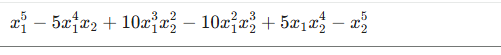

In [65]:
f5_expanded_x1x2 = Poly(f5_expanded, [x1, x2]) #多个参数使用列表
# 将x1、x2都看成是变量

coefficients = f5_expanded_x1x2.coeffs()
coefficients

[1, -5, 10, -10, 5, -1]

In [66]:
type(coefficients)
# 判断结果类型

list

In [67]:
# 判断元素类型
type(coefficients[0]) # sympy.core.numbers.One

sympy.core.numbers.One

###这段代码有问题

In [69]:
# 将数值转化为浮点数float

coefficients_float = eval(str(coefficients))
# 先将coefficients 转化为str，再转化为浮点数
coefficients_float

[1, -5, 10, -10, 5, -1]

In [72]:
print(type(coefficients_float[0]))
# 没有转为float

<class 'int'>


<StemContainer object of 3 artists>

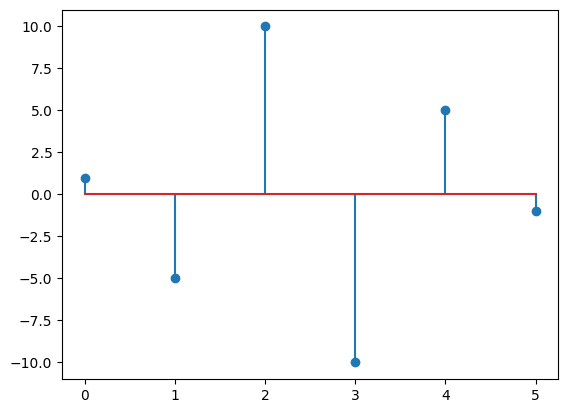

In [73]:
import matplotlib.pyplot as plt

plt.stem(coefficients_float)


## 解等式

In [74]:
from sympy import solve

equality = x**2 - 4
solve(equality, x) # 解函数；x为自变量

[-2, 2]

In [77]:
from sympy import solveset,Eq

solveset(Eq(x**2, 1), x) # Eq(x**2, 1)生成等式 x^2=1;自变量为x
# 集合

{-1, 1}

In [78]:
print(type(solveset(Eq(x**2, 1), x)))

<class 'sympy.sets.sets.FiniteSet'>


In [79]:
solveset(Eq(x**2 - 1, 0), x) # x^2-1=0

{-1, 1}

In [80]:
a,b,c = symbols("a,b,c", real=True) # abc为实数

equation = Eq(a*x**2+b*x, -c) # 生成等式 ax^2 + bx = -c

In [82]:
solve(equation, x) # 一元二次函数的根
# _ 是上一个cell计算结果

⎡        _____________          _____________⎤
⎢       ╱           2          ╱           2 ⎥
⎢-b - ╲╱  -4⋅a⋅c + b    -b + ╲╱  -4⋅a⋅c + b  ⎥
⎢─────────────────────, ─────────────────────⎥
⎣         2⋅a                    2⋅a         ⎦

## 阶乘、组合数、Gamma函数

#### 阶乘

In [83]:
from sympy import factorial
factorial(5)

120

阶乘是一个正整数的连乘积，通常表示为$n!$，
其中$n$是一个非负整数。阶乘的定义如下：
$$ n!=n \times (n-1) \times (n-2)\times ⋯\times 2\times 1$$
例如，4!=4×3×2×1=24。  
注意，0的阶乘为1，即0! = 1。  
阶乘在组合数学和数学分析中经常出现，是求排列和组合数的基本方法之一，同时也用于定义各种数学函数，如Gamma函数和Beta函数等。  
阶乘还出现在各种算法和计算中，如计算机科学中的递归算法和概率统计中的二项分布、多项分布、Dirichlet分布等。

In [84]:
factorial(x)

x!

#### 组合数

这一句的作用是从 SymPy 库中导入 binomial() 函数。  
binomial() 函数是计算组合数的函数，用于计算从 n 个不同元素中取出 k 个元素的组合数。  
组合数通常表示为 $C(n,k)$ 或 $C_n^k$。  
$$ C_n^k = \frac {n!}{k!(n-k)!} $$
binomial() 函数的参数为两个整数 n 和 k，返回值为整数型或 SymPy 的数值类型，表示从 n 个不同元素中取出 k 个元素的组合数。  
该函数在组合数学、概率统计、数学分析和计算机科学等领域经常被使用。

$$ C_5^4 = \frac {5!}{4!} = 5$$

In [85]:
from sympy import binomial

In [86]:
binomial(5, 4)

5

In [87]:
factorial(5)/factorial(4)

5

In [88]:
binomial(6, 3)

20

In [89]:
factorial(6)/factorial(3)

120

#### Gamma函数

Gamma函数是数学中的一种特殊函数，通常表示为$\Gamma(x)$，是阶乘函数的推广。  
它可以看作是从正整数阶乘函数$ n! $（$n$为正整数）推广到实数、复数和甚至负数的一种函数。  
Gamma函数的定义如下：
$$\Gamma(x) = \int_{0}^{\infty} t^{x-1} e^{-t} dt$$  
其中$x$是一个实数或复数。  
$ \Gamma(x) $ 在实数$x>0$时被定义为阶乘函数的推广，即$\Gamma(x) = (x-1)!$。  
Gamma函数具有许多重要的数学性质，如对于正整数$n$，有$\Gamma(n) =(n-1)!$；  
对于任意实数或复数$z$，有$ \Gamma(z + 1) =  z \Gamma(z)$。  
Gamma函数在数学物理学、概率论、统计学、数论、组合数学等领域广泛应用。

In [90]:
from sympy import gamma
gamma(5)

24

$$\Gamma(5) =(4-1)! = 4 \times 3 \times 2 \times 1 = 24$$

## 函数

### 引入更复杂的符号函数

In [91]:
from sympy import exp, cos, sin, sqrt

In [92]:
f_gaussian_x1 = exp(-x1**2)
f_gaussian_x1

    2
 -x₁ 
ℯ    

In [93]:
f_sin_x1 = sin(x1)
f_sin_x1

sin(x₁)

In [94]:
from sympy import log
log(x*y)

log(x⋅y)

In [97]:
solve(Eq(log(x), 100), x) # log(x)就是ln^x

⎡ 100⎤
⎣ℯ   ⎦

#### log展开

In [98]:
# 假设条件
from sympy import expand_log
x, y = symbols('x y', positive=True)
expand_log(log(x*y))  # 相乘为相加

log(x) + log(y)

In [99]:
expand_log(log(x**2))

2⋅log(x)

#### 三角函数展开

In [100]:
from sympy import expand_trig
expr = sin(2*x) + cos(2*x)

In [101]:
expand_trig(expr) # 展开三角式

                       2       
2⋅sin(x)⋅cos(x) + 2⋅cos (x) - 1

### Gamma函数

In [102]:
from sympy import gamma
gamma(x)

Γ(x)

gamma(x)/gamma(x - 2)

(x - 1)! / (x-3)!

In [103]:
simplify(gamma(x)/gamma(x - 2))#simplify简化

(x - 2)⋅(x - 1)

### 将符号变量替换成具体数值

In [104]:
f1

x + y

In [113]:
x, y = symbols('x y')  # 符号变量
f1 = x + y

# 直接使用符号名称作为字符串
f1_x_to_2 = f1.subs('x', 2)  # ✅ 使用字符串 'x'
# 或者
f1_x_to_2 = f1.subs(x, 2)    # ✅ 只要 x 没有被重新赋值

In [114]:
f1_x_to_2 = f1.subs(x, 2)
f1_x_to_2
# x = 1赋值运算对符号变量没有影响

y + 2

In [115]:
# 同时将x、y替换成数值
f1.subs([(x, 2), (y, 4)])

6

In [116]:
f1.evalf(subs={x: 2}) # 将符号解析式中未知量替换为具体数值


y + 2.0

In [117]:
f1.evalf(subs={x: 2, y: 4})

6.00000000000000

In [ ]:
# 也可以用subs() 将变量替换成其他变量、表达式

In [118]:
f1.subs(x, x**2)

 2    
x  + y

In [119]:
f1.subs(x, sin(x))

y + sin(x)

In [120]:
f1_ = f1.subs([(x, sin(x)), (y, -exp(-y**2))])
f1_

            2
          -y 
sin(x) - ℯ   

In [121]:
# 进一步替换
f1_.subs(sin(x),exp(x))

        2
 x    -y 
ℯ  - ℯ   

### 将符号函数转化为Python函数

In [122]:
# 一元函数

f_gaussian_x1

    2
 -x₁ 
ℯ    

In [123]:
from sympy import lambdify
f_gaussian_x1_fcn = lambdify(x1, f_gaussian_x1)
f_gaussian_x1_fcn

<function _lambdifygenerated(x1)>

In [124]:
import numpy as np
x1_array = np.linspace(-3,3,100)

f_x1_array = f_gaussian_x1_fcn(x1_array)
# 将x1_array的数据带入--函数；求取结果

In [125]:
f_x1_array

array([1.23409804e-04, 1.76880405e-04, 2.51663004e-04, 3.55441898e-04,
       4.98341956e-04, 6.93578905e-04, 9.58239105e-04, 1.31420010e-03,
       1.78919918e-03, 2.41805111e-03, 3.24400753e-03, 4.32023947e-03,
       5.71141054e-03, 7.49529149e-03, 9.76434838e-03, 1.26272156e-02,
       1.62099440e-02, 2.06568943e-02, 2.61311262e-02, 3.28141244e-02,
       4.09046897e-02, 5.06168338e-02, 6.21765240e-02, 7.58171567e-02,
       9.17736782e-02, 1.10275332e-01, 1.31537081e-01, 1.55749843e-01,
       1.83069765e-01, 2.13606872e-01, 2.47413509e-01, 2.84473089e-01,
       3.24689734e-01, 3.67879441e-01, 4.13763397e-01, 4.61964082e-01,
       5.12004693e-01, 5.63312339e-01, 6.15225287e-01, 6.67004372e-01,
       7.17848463e-01, 7.66913636e-01, 8.13335512e-01, 8.56253976e-01,
       8.94839317e-01, 9.28318712e-01, 9.56001871e-01, 9.77304662e-01,
       9.91769594e-01, 9.99082148e-01, 9.99082148e-01, 9.91769594e-01,
       9.77304662e-01, 9.56001871e-01, 9.28318712e-01, 8.94839317e-01,
      

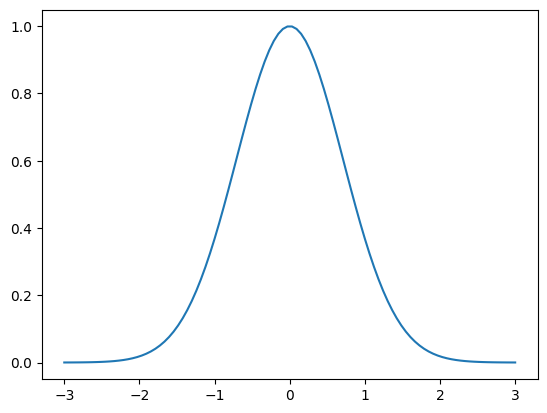

In [126]:
plt.plot(x1_array, f_x1_array) # 绘画

### 二元函数

In [127]:
f_gaussian_x1x2 = exp(-x1**2 - x2**2)
f_gaussian_x1x2

     2     2
 - x₁  - x₂ 
ℯ           

In [128]:
f_gaussian_x1x2_fcn = lambdify([x1,x2],f_gaussian_x1x2) # 将表达式转为函数；x1,x2两个自变量
f_gaussian_x1x2_fcn

<function _lambdifygenerated(x1, x2)>

In [129]:
xx1,xx2 = np.meshgrid(np.linspace(-3,3,100),np.linspace(-3,3,100))

-2 -1 0 1 2 ------  -2 -2 -2 -2 -2

-2 -1 0 1 2 ------  -1 -1 -1 -1 -1

-2 -1 0 1 2 ------   0 0 0 0 0

-2 -1 0 1 2 ------ 1 1 1 1 1

-2 -1 0 1 2  ------  2 2 2 2 2


In [131]:
print(xx1)
print("---------------")
print(xx2)

[[-3.         -2.93939394 -2.87878788 ...  2.87878788  2.93939394
   3.        ]
 [-3.         -2.93939394 -2.87878788 ...  2.87878788  2.93939394
   3.        ]
 [-3.         -2.93939394 -2.87878788 ...  2.87878788  2.93939394
   3.        ]
 ...
 [-3.         -2.93939394 -2.87878788 ...  2.87878788  2.93939394
   3.        ]
 [-3.         -2.93939394 -2.87878788 ...  2.87878788  2.93939394
   3.        ]
 [-3.         -2.93939394 -2.87878788 ...  2.87878788  2.93939394
   3.        ]]
---------------
[[-3.         -3.         -3.         ... -3.         -3.
  -3.        ]
 [-2.93939394 -2.93939394 -2.93939394 ... -2.93939394 -2.93939394
  -2.93939394]
 [-2.87878788 -2.87878788 -2.87878788 ... -2.87878788 -2.87878788
  -2.87878788]
 ...
 [ 2.87878788  2.87878788  2.87878788 ...  2.87878788  2.87878788
   2.87878788]
 [ 2.93939394  2.93939394  2.93939394 ...  2.93939394  2.93939394
   2.93939394]
 [ 3.          3.          3.         ...  3.          3.
   3.        ]]


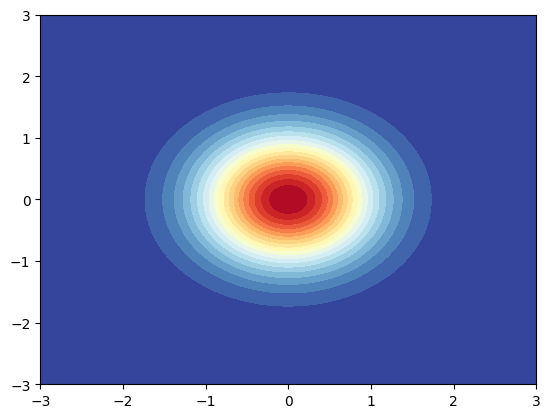

In [132]:
ff = f_gaussian_x1x2_fcn(xx1,xx2)  # 将数据xx1, xx2带入函数；相当于z值
plt.contourf(xx1,xx2,ff, levels = 20, cmap = 'RdYlBu_r')

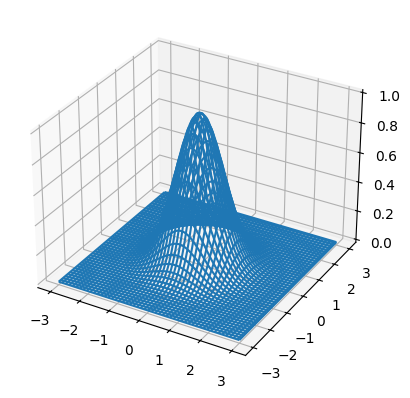

In [133]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.plot_wireframe(xx1,xx2,ff)

In [ ]:
# Repo: https://github.com/Visualize-ML
# Book 1 Python for Beginners  |  From Basic Arithmetic to Machine Learning
# Published and copyrighted by Tsinghua University Press
# Beijing, China, 2023